# Сравнение функций потерь для обучения текстовых эмбеддингов

Эксперимент обучает только переинициализированную projection head модели `sentence-transformers/msmarco-distilbert-base-dot-prod-v3`. Transformer backbone и pooling заморожены. Датасеты заранее приведены к одинаковому размеру: 5000 train-записей и 1000 test-записей на применимое представление.

In [1]:
from pathlib import Path

import pandas as pd

from dataset_prep import verify_outputs
from early_stop_next import main as run_early_stop_experiments

DATA_DIR = Path("data") / "processed"
ARTIFACTS_DIR = Path("artifacts")


C:\Users\gorku\Documents\bmstu\m2\mmo\mmo-rk-1\hw\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Проверка подготовленных данных

In [2]:
dataset_summary = verify_outputs(DATA_DIR)
pd.DataFrame(dataset_summary)

,dataset_id,view,split,rows,columns,labels
0,all_nli,contrastive_pair,test,1000,"anchor,other,label,source_dataset,split",0:500;1:500
1,all_nli,contrastive_pair,train,5000,"anchor,other,label,source_dataset,split",0:2500;1:2500
2,all_nli,positive_pair,test,1000,"anchor,positive,label,source_dataset,split",1:1000
3,all_nli,positive_pair,train,5000,"anchor,positive,label,source_dataset,split",1:5000
4,all_nli,triplet,test,1000,"anchor,positive,negative,label,source_dataset,...",1:1000
5,all_nli,triplet,train,5000,"anchor,positive,negative,label,source_dataset,...",1:5000
6,banking77,class_text,test,1000,"text,label,label_text,source_dataset,split",classes=77;min=12;max=13
7,banking77,class_text,train,5000,"text,label,label_text,source_dataset,split",classes=77;min=17;max=94
8,banking77,contrastive_pair,test,1000,"anchor,other,label,source_dataset,split",0:500;1:500
9,banking77,contrastive_pair,train,5000,"anchor,other,label,source_dataset,split",0:2500;1:2500


## Запуск сравнения

Для каждой функции потерь projection head заново инициализируется с одинаковым seed. Обучаются только параметры `Dense(768, 768, bias=False)`.

In [3]:
import json

FORCE_RECOMPUTE = False
results_path = ARTIFACTS_DIR / "results.json"

if FORCE_RECOMPUTE or not results_path.exists():
    run_early_stop_experiments()

results = json.loads(results_path.read_text(encoding="utf-8"))
len(results["runs"])


20

## Сводная таблица результатов

In [4]:
summary = pd.read_csv(ARTIFACTS_DIR / "metrics_summary.csv")
summary.sort_values(["dataset_id", "primary_metric_name", "primary_metric"], ascending=[True, True, False])

,best_epoch,best_val_metric,circle_margin,contrastive_margin,dataset_id,epochs_ran,final_train_loss,final_train_metric,final_val_loss,final_val_metric,...,loss,max_epochs,primary_metric,primary_metric_name,stsb_spearman,temperature,test_primary_metric,triplet_margin,view,weight_decay
0,5,0.762803,NaN,0.6,all_nli,7,0.095457,0.954311,0.150685,0.762803,...,contrastive,12,0.756852,pair_auc,0.707088,NaN,0.756852,NaN,contrastive_pair,0.0001
2,1,0.753000,NaN,NaN,all_nli,3,0.788968,0.702250,0.682631,0.753000,...,infonce,12,0.769000,retrieval_top1,0.792856,0.05,0.769000,NaN,positive_pair,0.0000
3,1,0.747000,NaN,NaN,all_nli,3,0.774443,0.708250,0.771632,0.747000,...,nt_xent,12,0.758000,retrieval_top1,0.792763,0.05,0.758000,NaN,positive_pair,0.0000
1,2,0.869000,NaN,NaN,all_nli,4,0.040609,0.953250,0.064879,0.869000,...,triplet,8,0.866000,triplet_accuracy,0.734971,NaN,0.866000,0.2,triplet,0.0000
13,6,0.880000,0.25,NaN,banking77,8,14.049911,0.927750,16.406897,0.880000,...,circle,10,0.903000,knn1_accuracy,0.751920,NaN,0.903000,NaN,class_text,0.0000
12,2,0.878000,NaN,NaN,banking77,4,2.485595,0.896750,2.579071,0.878000,...,supcon,12,0.879000,knn1_accuracy,0.749919,0.05,0.879000,NaN,class_text,0.0000
8,12,0.974028,NaN,0.4,banking77,12,0.076031,0.992349,0.109263,0.974028,...,contrastive,12,0.971892,pair_auc,0.687181,NaN,0.971892,NaN,contrastive_pair,0.0010
10,3,0.066000,NaN,NaN,banking77,5,2.306607,0.010750,2.701705,0.066000,...,infonce,12,0.019000,retrieval_top1,0.746487,0.05,0.019000,NaN,positive_pair,0.0000
11,6,0.073000,NaN,NaN,banking77,8,2.006059,0.014500,2.513940,0.073000,...,nt_xent,12,0.018000,retrieval_top1,0.726662,0.05,0.018000,NaN,positive_pair,0.0010
9,4,0.966000,NaN,NaN,banking77,6,0.001559,0.999500,0.018994,0.966000,...,triplet,10,0.974000,triplet_accuracy,0.763979,NaN,0.974000,0.2,triplet,0.0000


## Графики

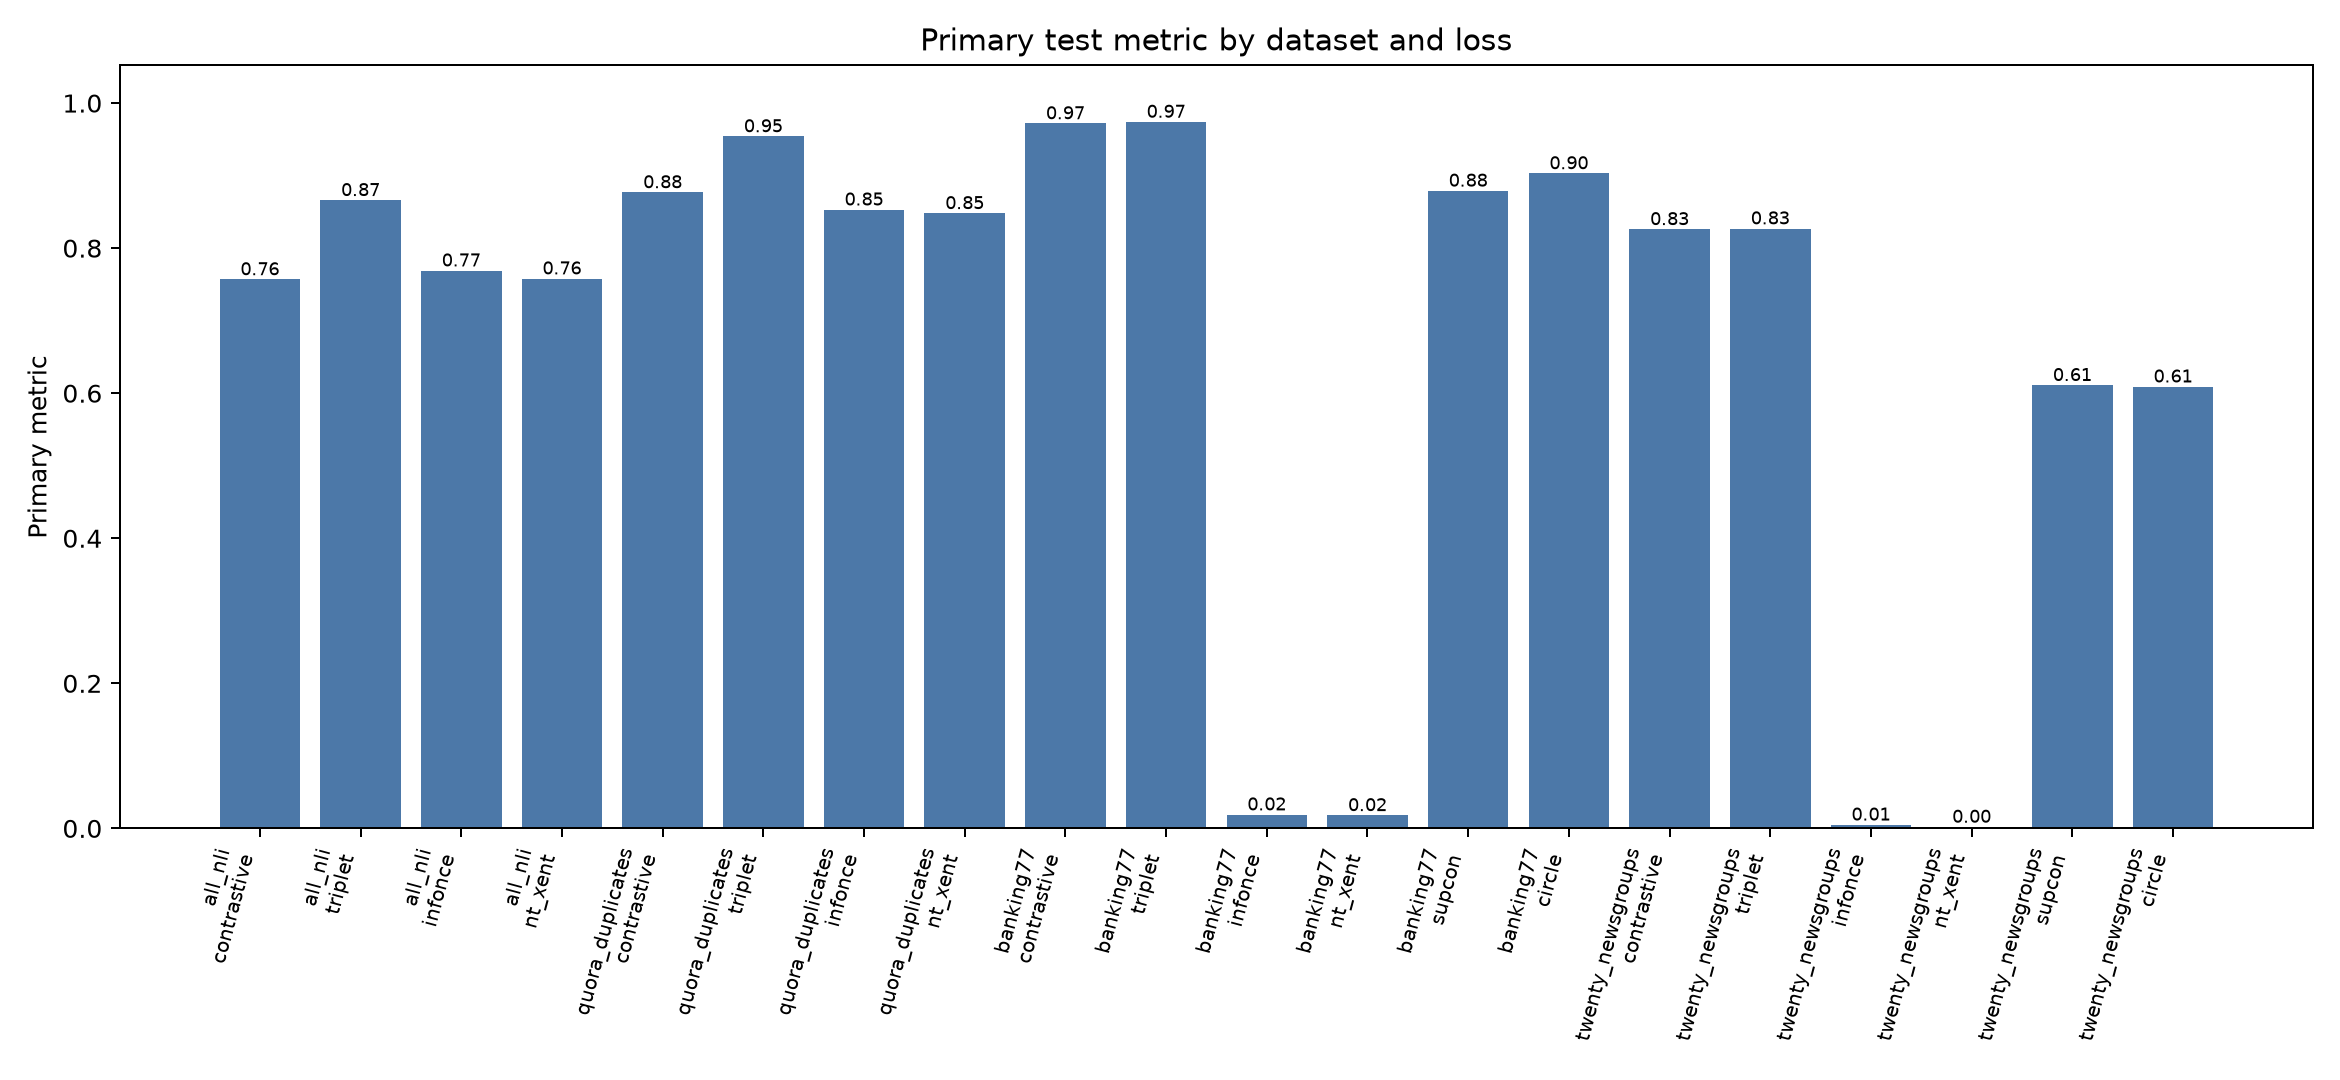

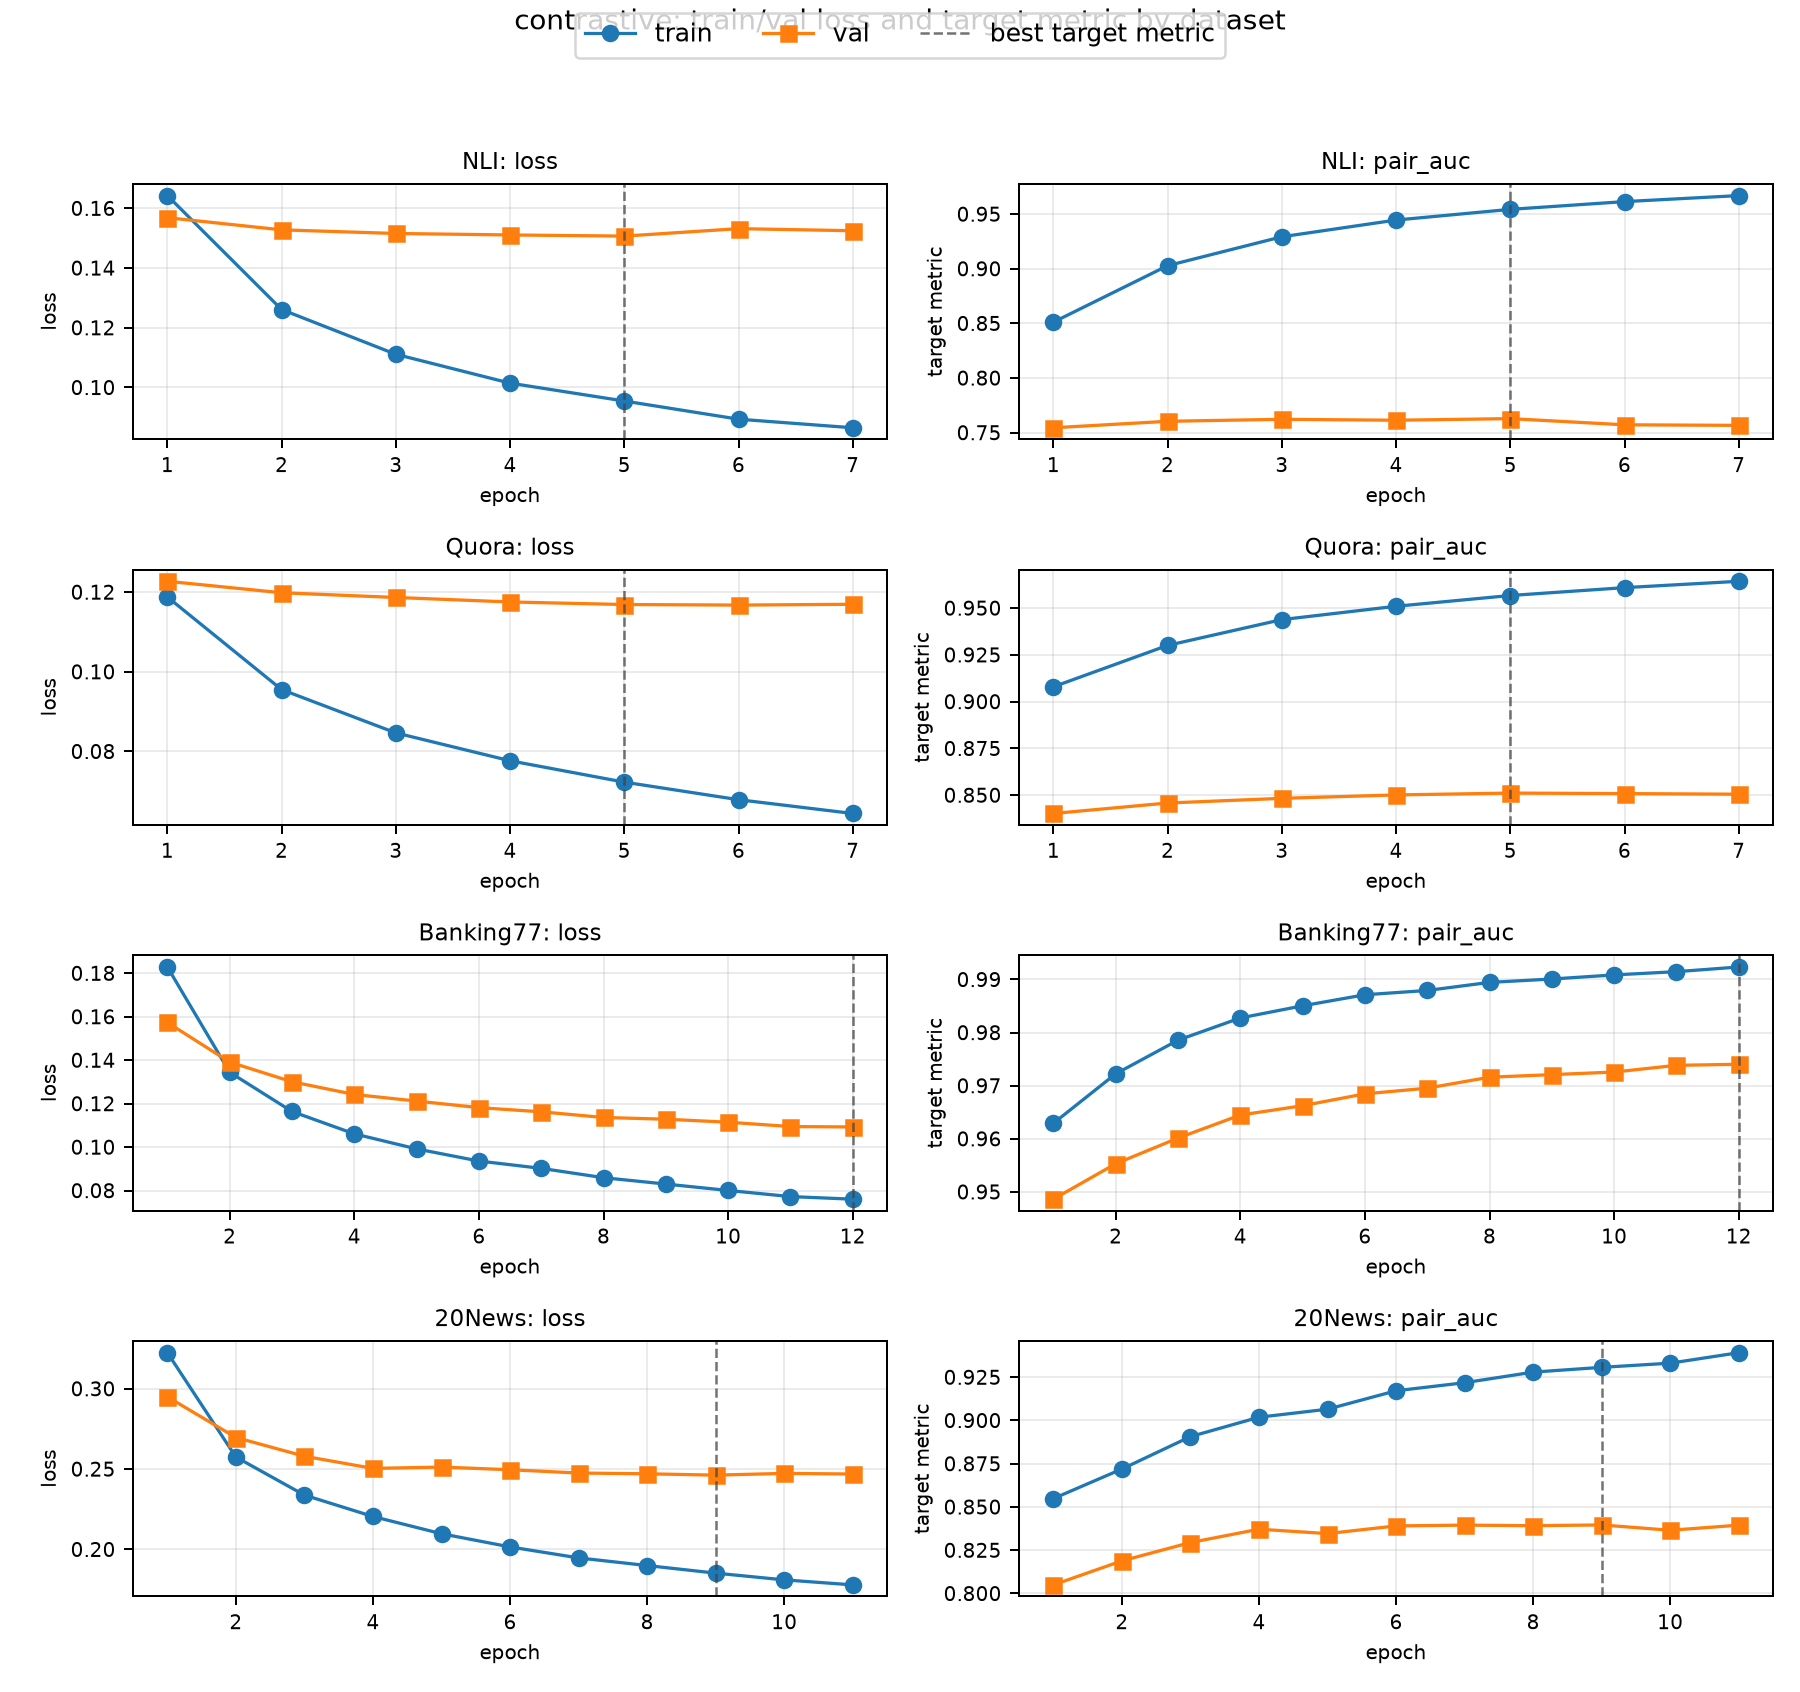

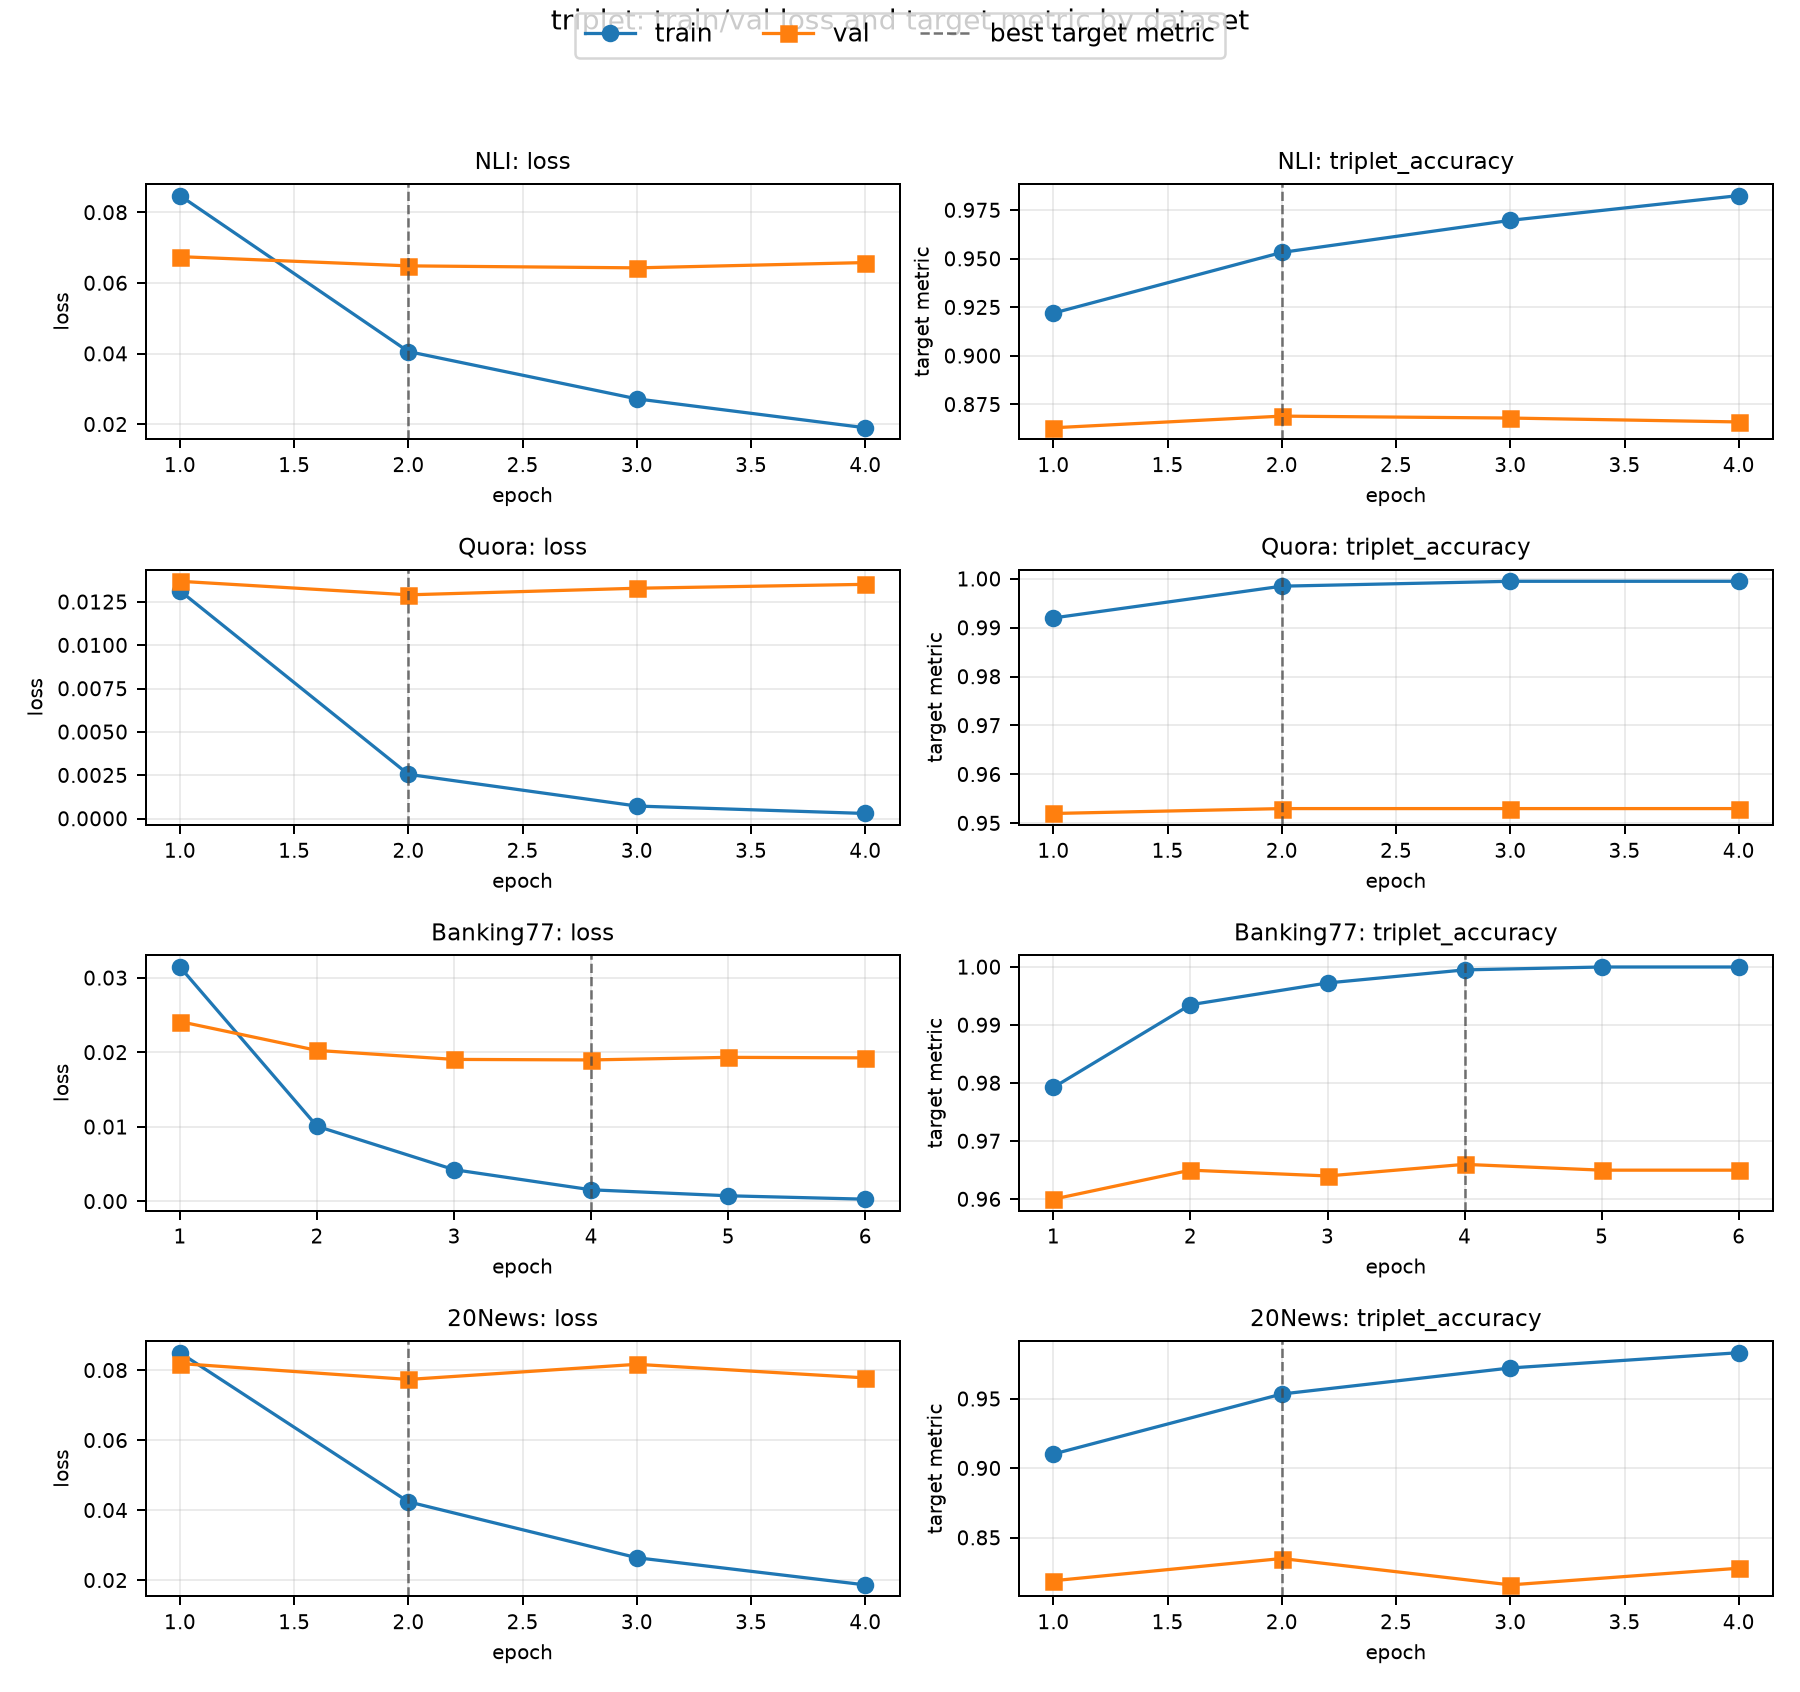

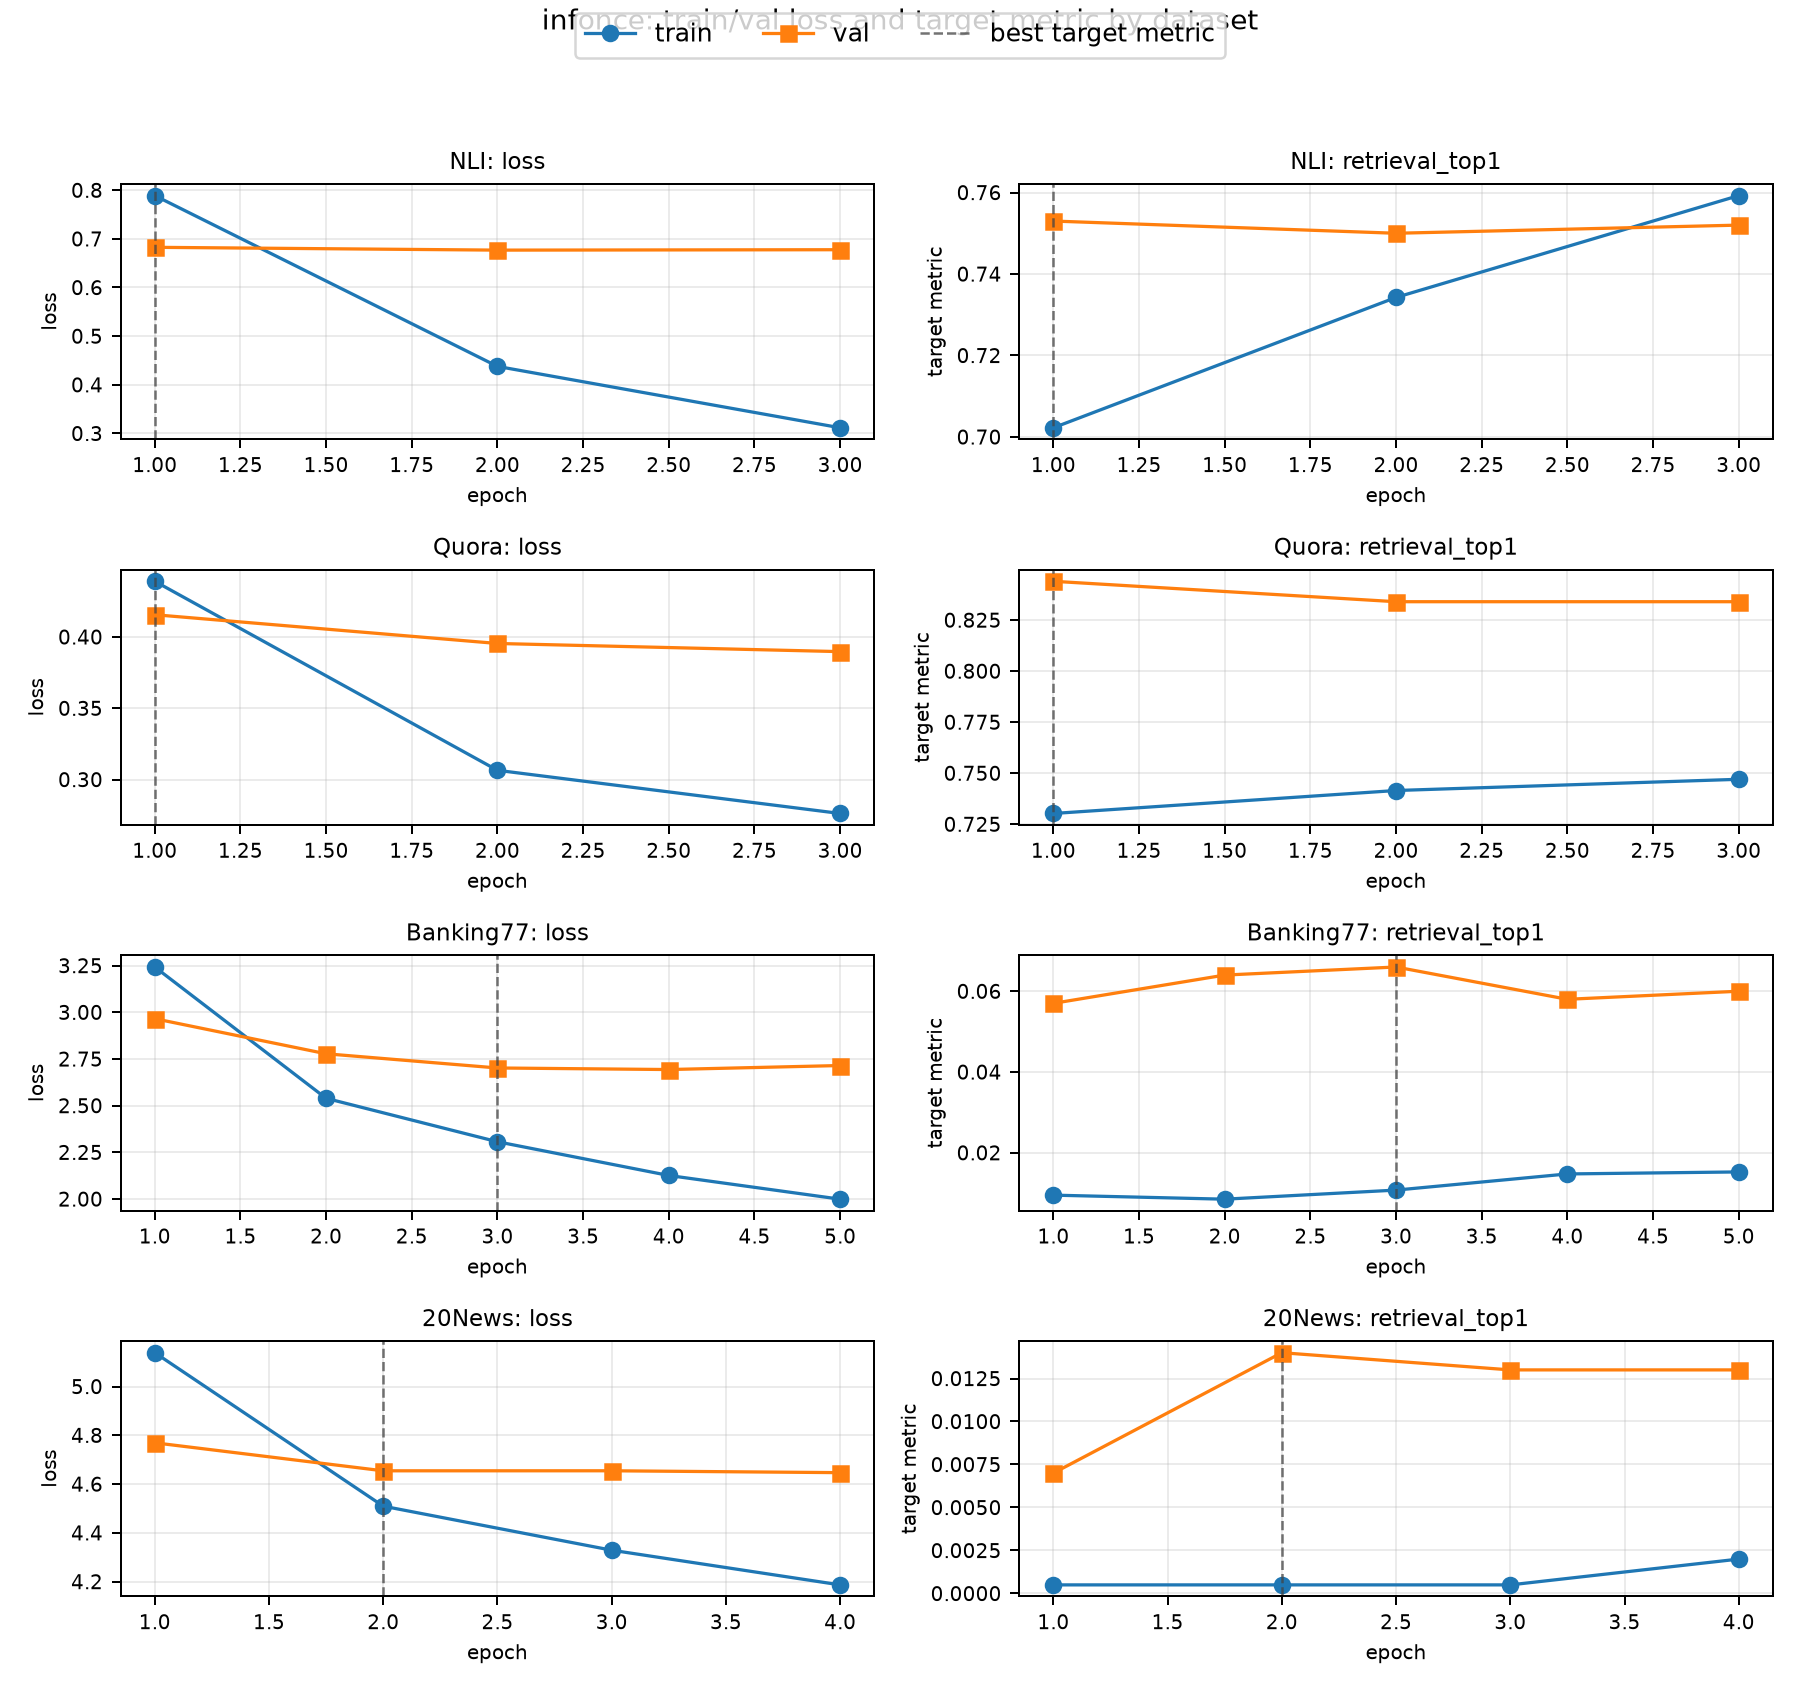

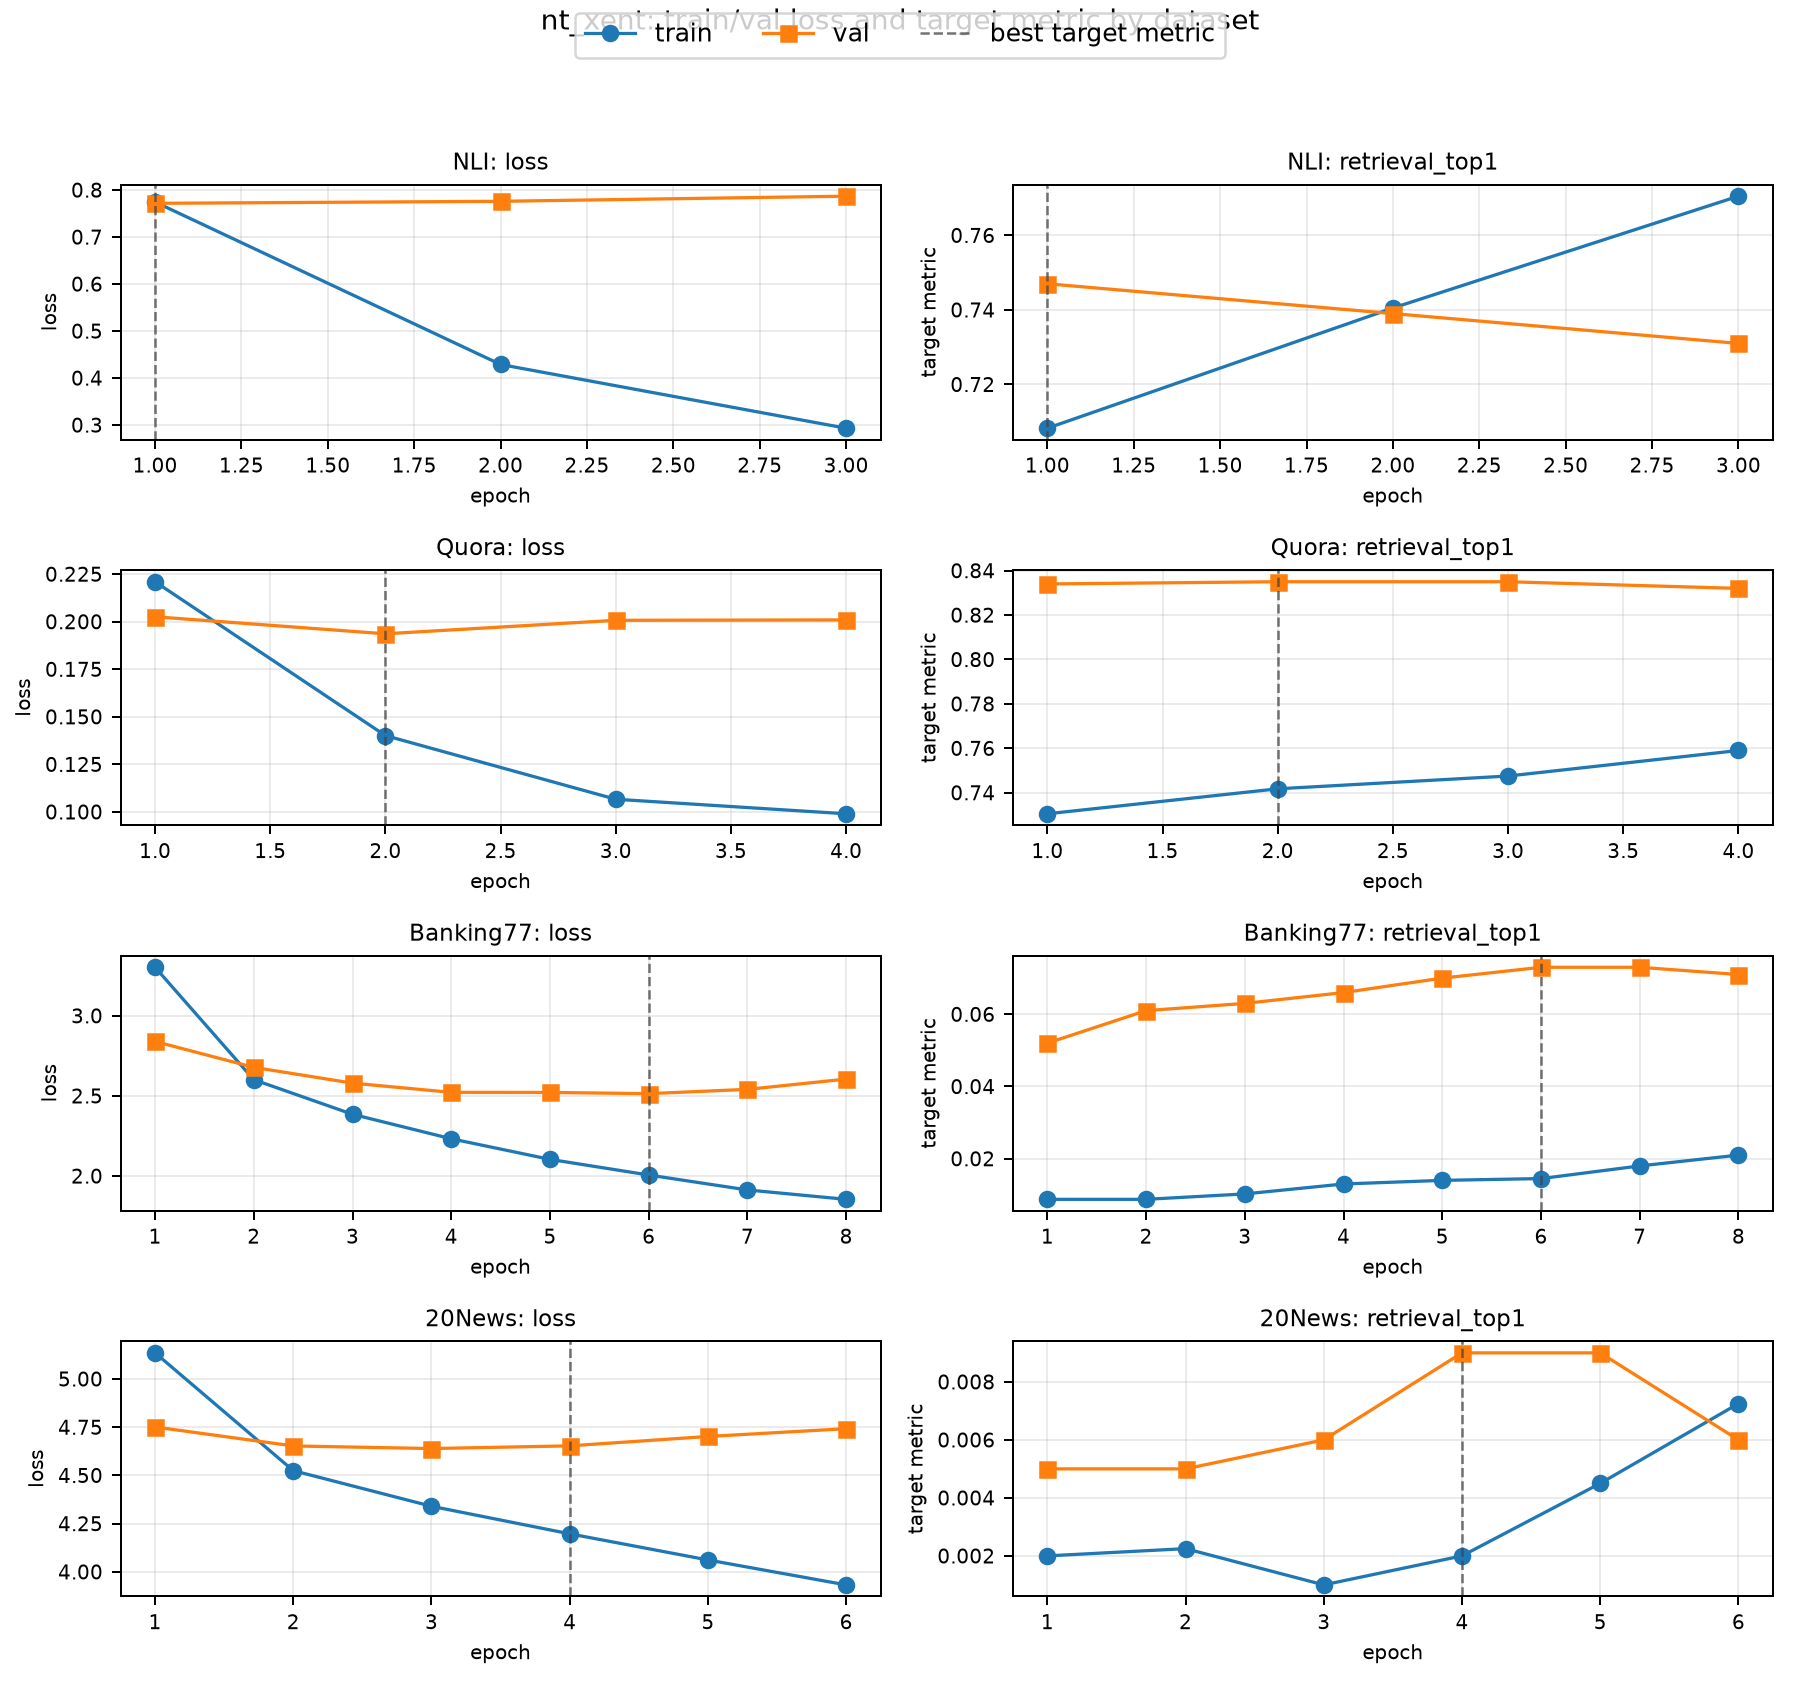

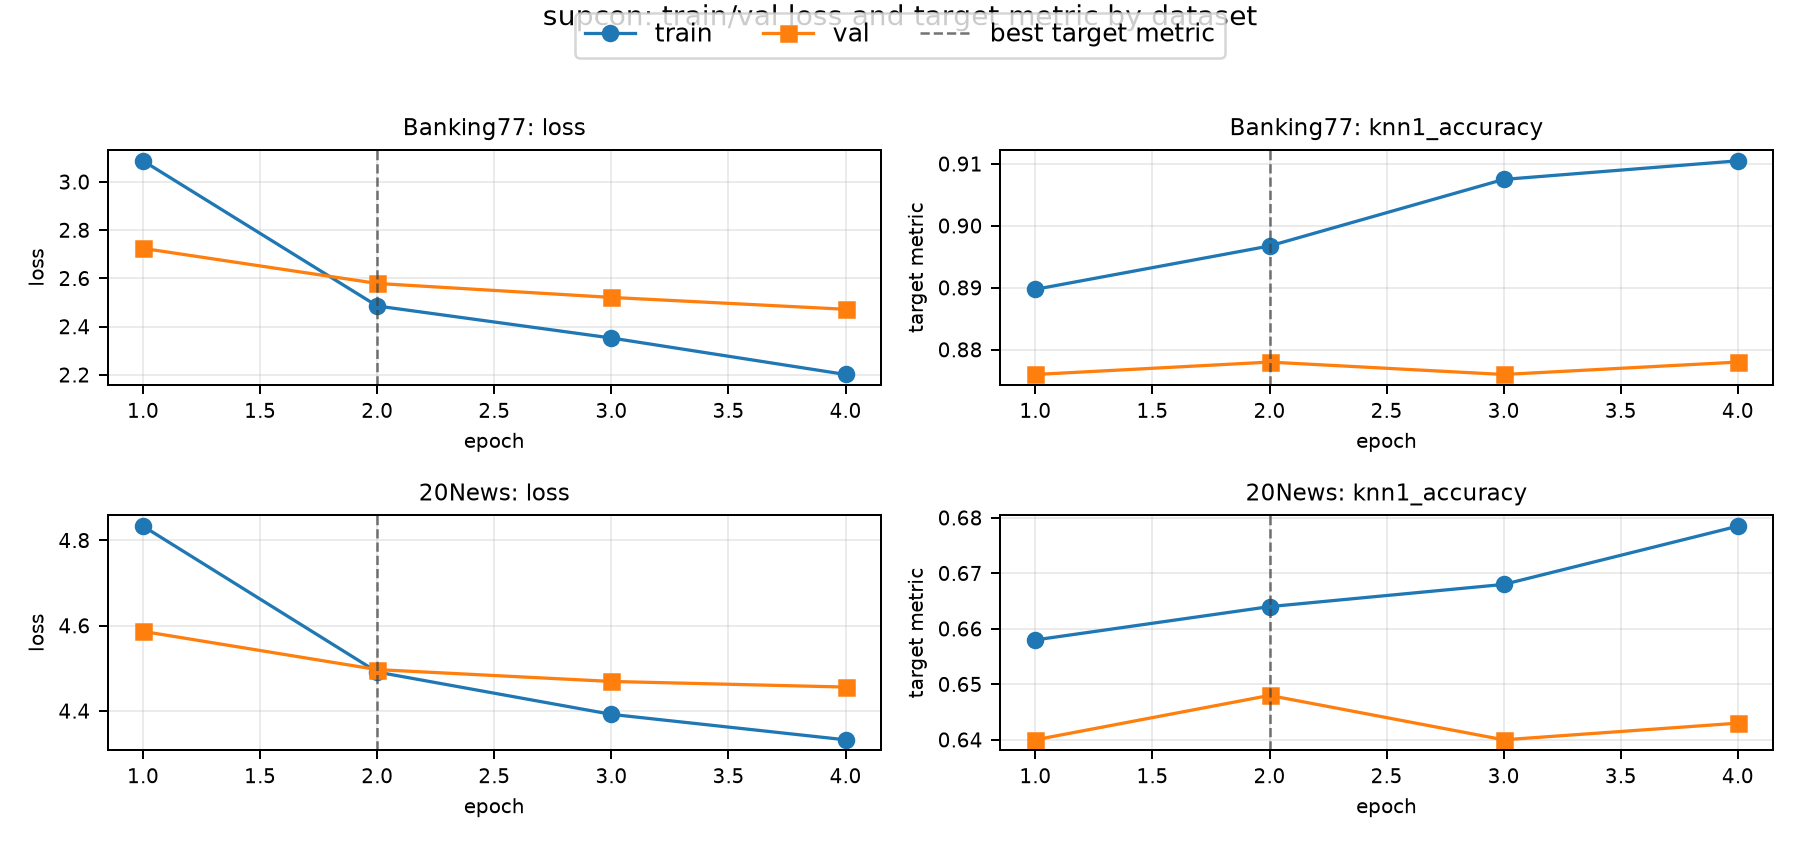

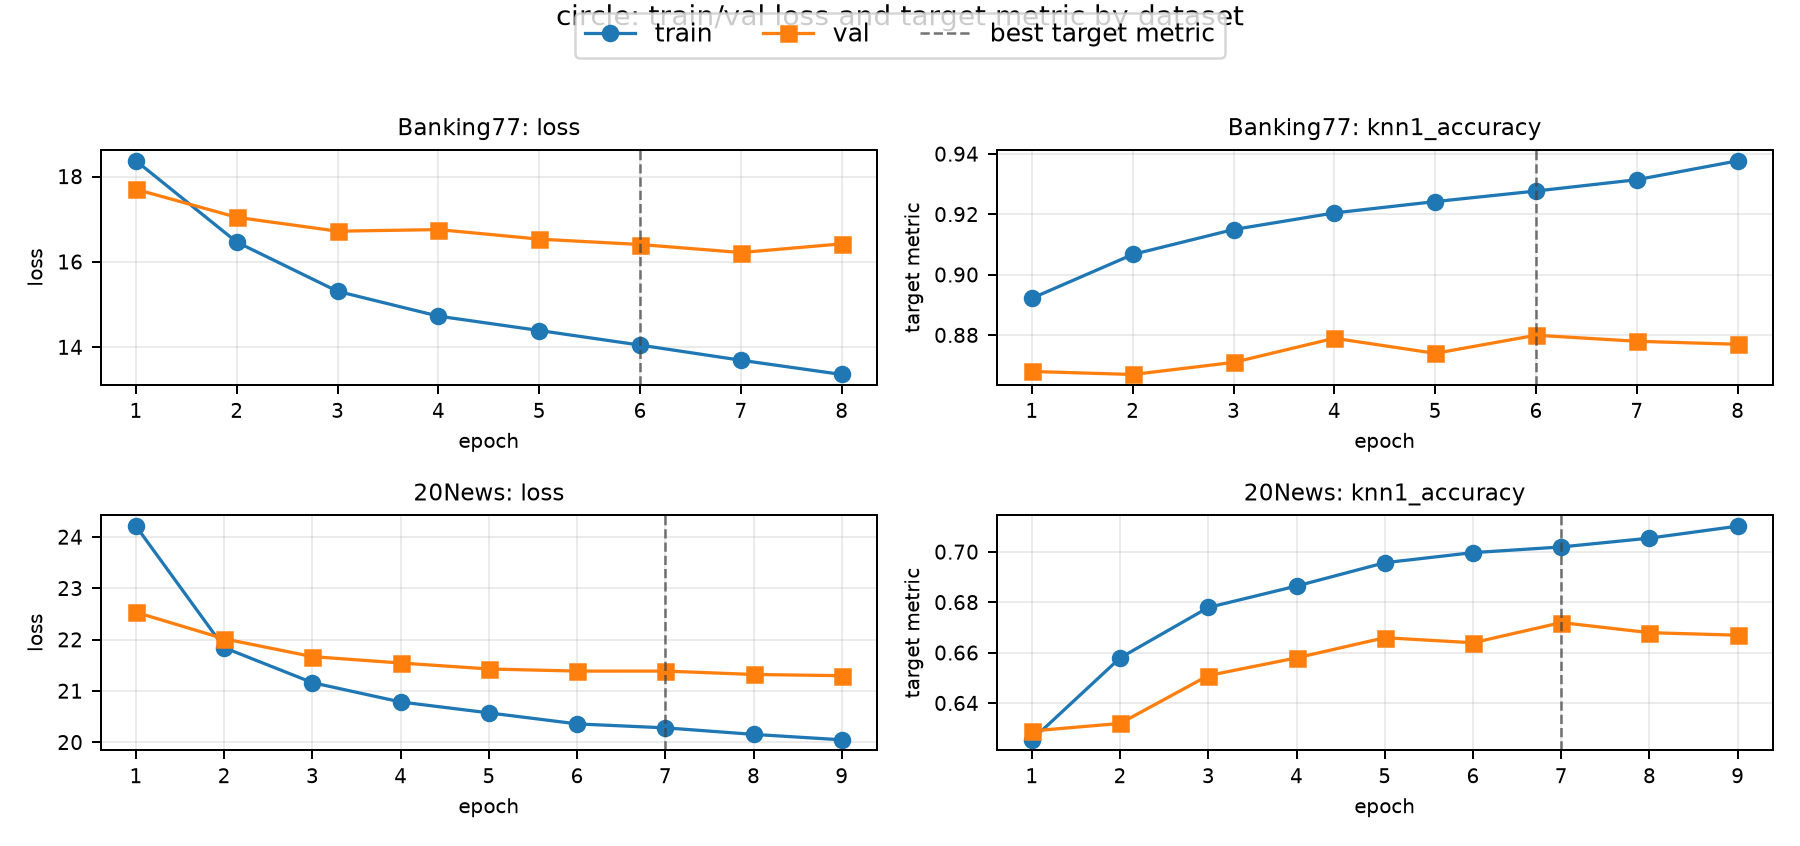

In [5]:
from IPython.display import Image, display

display(Image(filename=str(ARTIFACTS_DIR / "plots" / "primary_metrics.png")))
for loss_name in ["contrastive", "triplet", "infonce", "nt_xent", "supcon", "circle"]:
    display(Image(filename=str(ARTIFACTS_DIR / "plots" / f"loss_panels_by_loss_{loss_name}.png")))
